# Chicago Taxi Data - Exploratory Data Analysis

**Project:** AAA Team Assignment - Ride-Hailing for Electric Vehicle Fleet  
**Dataset:** Chicago Taxi Trips 2024-2026 (Chicago Data Portal)  
**Preprocessing:** Cleaning is performed in `00_data_loading.ipynb` -> input: `chicago_taxi_2024_2026_clean.parquet`

### Notebook Structure
1. Setup & Data Loading
2. Basic Dataset Overview
3. Temporal Patterns
4. Trip Characteristics (Distance, Duration, Price)
5. Spatial Overview
6. Results and Key Takeaways

## 1. Setup & Data Loading

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [42]:
# ── Load cleaned data ─────────────────────────────────────────────────────────
PARQUET_PATH = '../../data/chicago_taxi_2024_2026_clean.parquet'

print(f'Loading: {PARQUET_PATH}')
df_taxi = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(df_taxi):,} rows and {df_taxi.shape[1]} columns.')
df_taxi.head(10)

Loading: ../../data/chicago_taxi_2024_2026_clean.parquet
Loaded 14,465,662 rows and 27 columns.


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_flag,dropoff_flag,pickup_ca_centroid_lat,pickup_ca_centroid_lon,dropoff_ca_centroid_lat,dropoff_ca_centroid_lon
0,cd9efc3a2f17e7807815b85da5243858aa220972,c53face33b74e90c719c30c33f394050ca1e93ca6b11a8...,2024-01-07 23:45:00,2024-01-08 00:15:00,2530.0,9.200000,NaN,NaN,3,<NA>,...,41.965813,-87.655876,NaN,NaN,1,0,41.965813,-87.655876,NaN,NaN
1,c24cefb09bac1ecb318b96b59b9a424e460ef29e,2e7f98f477c93ec4c458c0f46cad563cc83e813d5ebc0d...,2024-01-07 23:45:00,2024-01-08 00:15:00,1107.0,14.040000,NaN,NaN,76,22,...,41.980263,-87.913628,41.922760,-87.699158,1,1,41.980263,-87.913628,41.922760,-87.699158
2,b6f5e763d27a57350f8f7e42396d9341d887e203,eb7536e0b280d7842bd4448d3fc93ca078630c2f39f122...,2024-01-07 23:45:00,2024-01-08 00:30:00,3295.0,26.559999,NaN,NaN,76,39,...,41.980263,-87.913628,41.808918,-87.596184,1,1,41.980263,-87.913628,41.808918,-87.596184
3,b6af7c1364cc4c8cf4dbb61f746116682d10b768,cefcf124c1b1156a94b0d3c6edd07763849c63f800638f...,2024-01-07 23:45:00,2024-01-08 00:00:00,660.0,0.200000,NaN,NaN,76,76,...,41.980263,-87.913628,41.980263,-87.913628,1,1,41.980263,-87.913628,41.980263,-87.913628
4,aa07462edd535624bc66e0d91d327370af946c90,d5dc4a704805faed89d18144387c3f5f9150df85c6ea5d...,2024-01-07 23:45:00,2024-01-08 00:00:00,1175.0,16.280001,NaN,NaN,76,28,...,41.980263,-87.913628,41.874004,-87.663521,1,1,41.980263,-87.913628,41.874004,-87.663521
5,9f4391e80166a94c4902ceaf554909203f81cefb,11f73b08790612efe341cf8cf69cadbcb7732293794186...,2024-01-07 23:45:00,2024-01-08 00:00:00,900.0,8.600000,NaN,NaN,33,3,...,41.857185,-87.620331,41.965813,-87.655876,1,1,41.857185,-87.620331,41.965813,-87.655876
6,94768c55269efc39b41551fbd7456ad6a84765f2,6dcd43a953f0c1bdfc49fe8260b9504af2cc45eefdfc22...,2024-01-07 23:45:00,2024-01-08 00:15:00,1212.0,17.820000,NaN,NaN,76,8,...,41.980263,-87.913628,41.899601,-87.633308,1,1,41.980263,-87.913628,41.899601,-87.633308
7,04e40c7d73e387e8516d7e69be774e6cf838447e,6dbac74c2838addb28d0bf34cf126cf1624cc61180bfb2...,2024-01-07 23:45:00,2024-01-08 00:15:00,1741.0,18.370001,1.703198e+10,NaN,76,<NA>,...,41.979073,-87.903038,NaN,NaN,1,0,41.980263,-87.913628,NaN,NaN
8,0ebab4b1c5e7f2c7f9989ac407b12be8f85967e0,761789d686c96d6a313aecc3d5080955d5353b3a7f8d89...,2024-01-07 23:45:00,2024-01-08 00:00:00,1409.0,15.510000,NaN,NaN,76,24,...,41.980263,-87.913628,41.901207,-87.676353,1,1,41.980263,-87.913628,41.901207,-87.676353
9,12ce6337235c0cc1c222858a9d96f723b2ac0524,cf278f6c67e799170264672cf78527e136318d96aefd5f...,2024-01-07 23:45:00,2024-01-07 23:45:00,563.0,4.320000,NaN,NaN,76,76,...,41.980263,-87.913628,41.980263,-87.913628,1,1,41.980263,-87.913628,41.980263,-87.913628


## 2. Basic Dataset Overview

In [43]:
# Schema: column names, dtypes, non-null counts
print('=== Dataset Info ===')
df_taxi.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14465662 entries, 0 to 14465661
Data columns (total 27 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     object        
 1   taxi_id                     object        
 2   trip_start_timestamp        datetime64[us]
 3   trip_end_timestamp          datetime64[us]
 4   trip_seconds                float32       
 5   trip_miles                  float32       
 6   pickup_census_tract         float32       
 7   dropoff_census_tract        float32       
 8   pickup_community_area       Int64         
 9   dropoff_community_area      Int64         
 10  fare                        float32       
 11  tips                        float32       
 12  tolls                       float32       
 13  extras                      float32       
 14  trip_total                  float32       
 15  payment_type                category      


In [44]:
# Date range covered by the dataset
print(f'Earliest trip : {df_taxi["trip_start_timestamp"].min()}')
print(f'Latest trip   : {df_taxi["trip_start_timestamp"].max()}')

Earliest trip : 2024-01-01 00:00:00
Latest trip   : 2026-05-31 23:45:00


## 3. Temporal Patterns

This section analyzes temporal demand patterns at several levels of discretization, as required for the subsequent modeling task. Hourly data preserve short demand peaks, multi-hour blocks provide progressively smoother operating periods, and daily aggregation reveals longer-term variation. Weekday and weekend profiles are analyzed separately to identify recurring weekly behavior. Comparisons involving calendar periods are normalized where necessary, so the partial 2026 data do not distort the interpretation.

In [45]:
# Extract temporal features
df_taxi['hour']         = df_taxi['trip_start_timestamp'].dt.hour
df_taxi['weekday']      = df_taxi['trip_start_timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
df_taxi['weekday_name'] = df_taxi['trip_start_timestamp'].dt.day_name()
df_taxi['month']        = df_taxi['trip_start_timestamp'].dt.month
df_taxi['month_name']   = df_taxi['trip_start_timestamp'].dt.month_name()
df_taxi['is_weekend']   = df_taxi['weekday'].isin([5, 6])
df_taxi['date']         = df_taxi['trip_start_timestamp'].dt.date

print('Temporal features added.')

Temporal features added.


### 3.1 Daily and Weekly Demand Profiles

The first temporal pattern describes how demand changes within a typical day and across the week. Profiles are normalized by the number of observed calendar days, avoiding cumulative weekday comparisons that would be distorted when particular weekdays occur a different number of times in the partial 2026 period. The resulting pattern distinguishes regular weekday mobility from lower weekend demand.

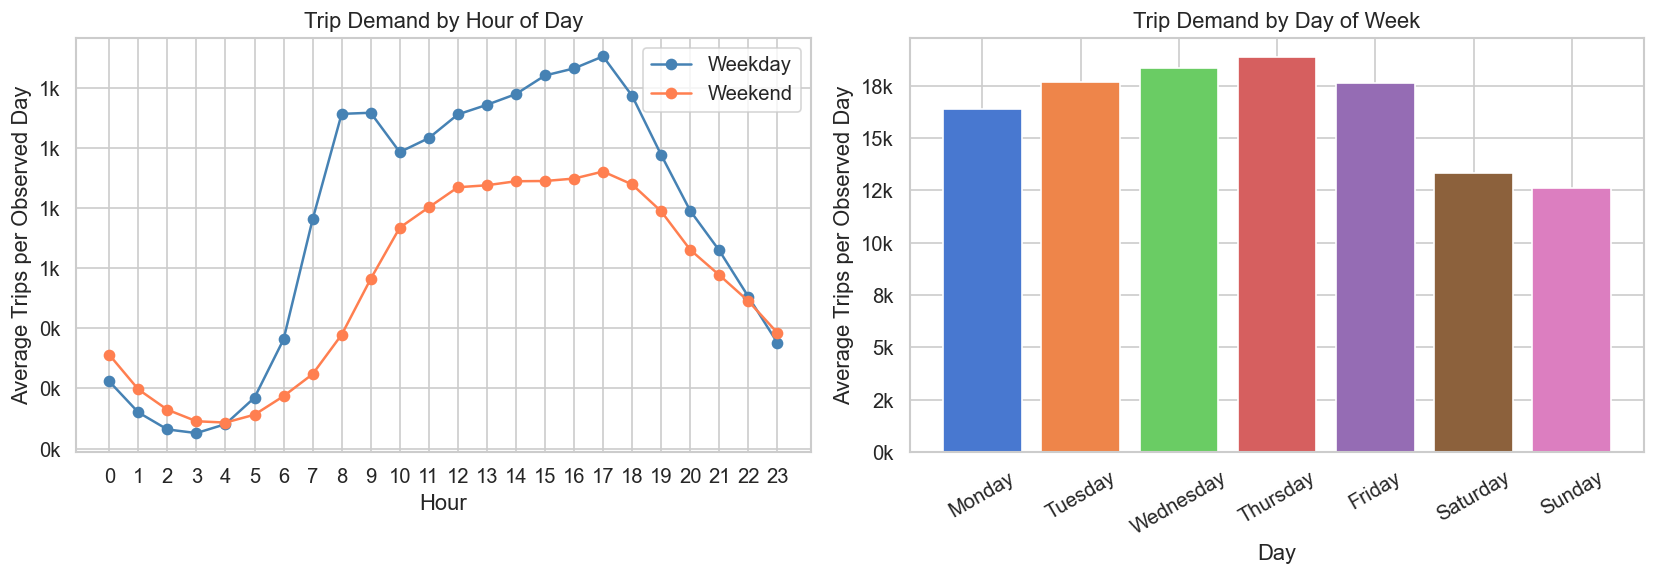

In [46]:
# ── Trips per hour of day ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekday vs weekend, normalized by the number of observed calendar days
daily_hourly = df_taxi.groupby(['date', 'hour', 'is_weekend']).size().reset_index(name='trips')
hourly = daily_hourly.groupby(['hour', 'is_weekend'])['trips'].mean().reset_index()
for is_we, label, color in [(False, 'Weekday', 'steelblue'), (True, 'Weekend', 'coral')]:
    subset = hourly[hourly['is_weekend'] == is_we]
    axes[0].plot(subset['hour'], subset['trips'], marker='o', label=label, color=color)
axes[0].set_title('Trip Demand by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Trips per Observed Day')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# By day of week
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_by_weekday = df_taxi.groupby(['date', 'weekday_name']).size().reset_index(name='trips')
trips_by_day = daily_by_weekday.groupby('weekday_name')['trips'].mean().reindex(weekday_order)
axes[1].bar(trips_by_day.index, trips_by_day.values, color=sns.color_palette('muted'))
axes[1].set_title('Trip Demand by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Trips per Observed Day')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

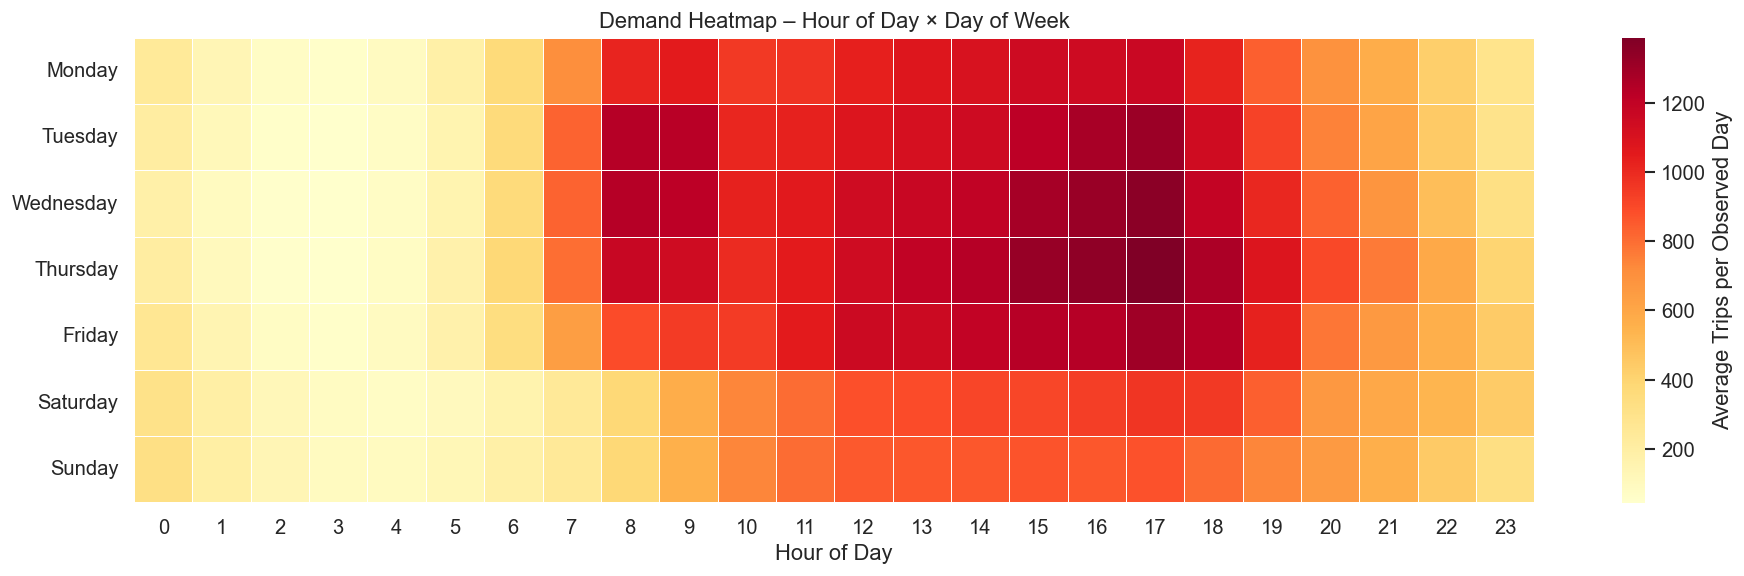

In [47]:
# ── Heatmap: hour × weekday ───────────────────────────────────────────────────
daily_hour_weekday = (df_taxi.groupby(['date', 'weekday_name', 'hour'])
                              .size().reset_index(name='trips'))
pivot = daily_hour_weekday.pivot_table(index='weekday_name', columns='hour',
                                        values='trips', aggfunc='mean')
pivot = pivot.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': 'Average Trips per Observed Day'})
ax.set_title('Demand Heatmap – Hour of Day × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 3.2 Demand Across the Observation Period

Daily discretization provides a longer-term view of the temporal pattern. Individual daily totals retain day-specific variation, while the centered seven-day rolling mean suppresses weekday effects and short-lived volatility. This makes broader changes over the January 2024 to May 2026 observation period visible without treating incomplete 2026 as a full calendar year.

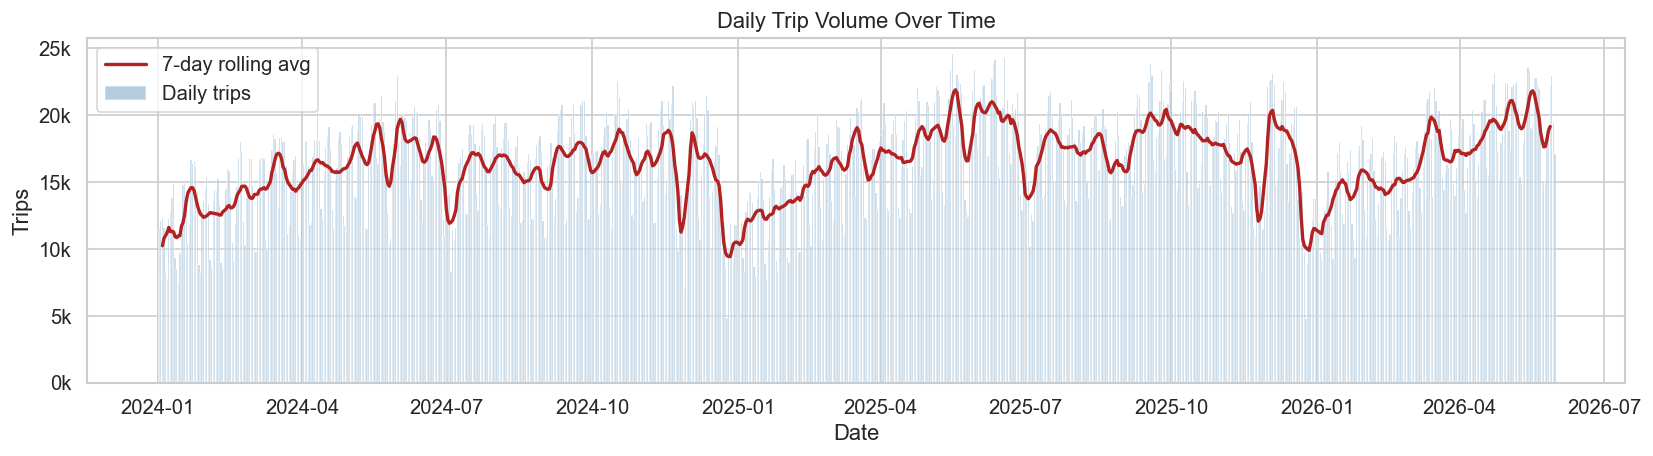

In [48]:
# ── Daily trip volume over time ───────────────────────────────────────────────
daily_trips = df_taxi.groupby('date').size().reset_index(name='trips')
daily_trips['date'] = pd.to_datetime(daily_trips['date'])
daily_trips['rolling_7d'] = daily_trips['trips'].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_trips['date'], daily_trips['trips'], color='steelblue', alpha=0.4, label='Daily trips')
ax.plot(daily_trips['date'], daily_trips['rolling_7d'], color='firebrick', linewidth=2, label='7-day rolling avg')
ax.set_title('Daily Trip Volume Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Temporal Discretization and Pattern Comparison

To evaluate the effect of temporal discretization explicitly, demand is compared at hourly, two-hour, three-hour, four-hour, and daily resolution. Hourly observations retain short-lived peaks but are comparatively noisy. Multi-hour intervals progressively smooth the same underlying temporal pattern, making broader operating periods easier to distinguish. Daily aggregation removes the within-day pattern and is therefore more suitable for longer-term capacity planning than intraday vehicle positioning. The comparison motivates the use of both one-hour and four-hour windows in the predictive analysis: one-hour windows preserve operational detail, whereas four-hour windows provide a more stable planning signal.

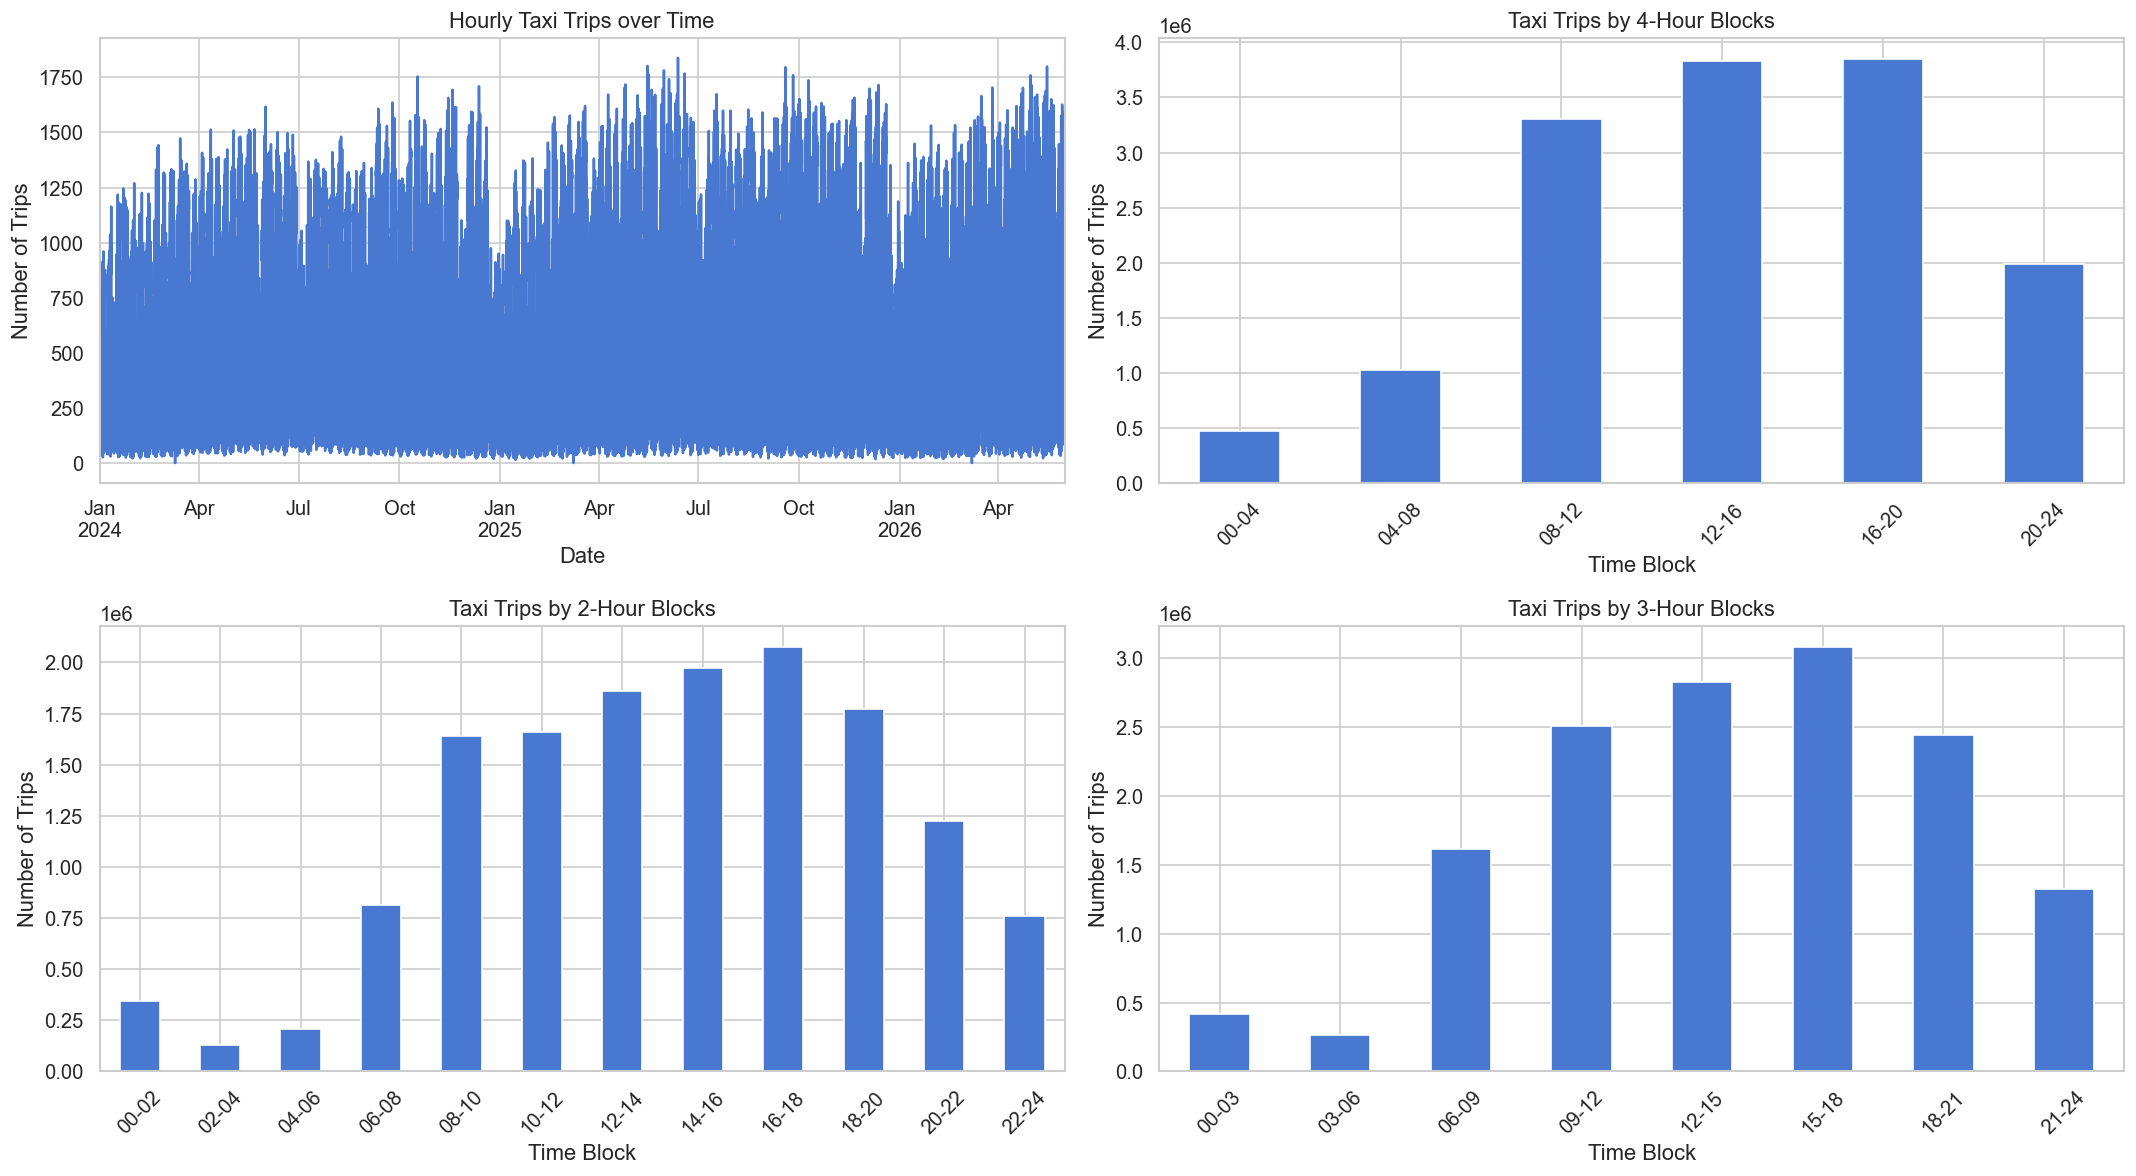

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract Hour
df_taxi["hour"] = df_taxi["trip_start_timestamp"].dt.hour

# 1) Hourly aggregation over the year
hourly = (
    df_taxi
    .set_index("trip_start_timestamp")
    .resample("1h")
    .size()
)

# 2) Time Block Feature
def create_block_profile(df, block_size):
    bins = list(range(0, 25, block_size))
    
    # If 24 is not included exactly, add it
    if bins[-1] != 24:
        bins.append(24)
    
    labels = [
        f"{bins[i]:02d}-{bins[i+1]:02d}"
        for i in range(len(bins) - 1)
    ]
    
    time_block = pd.cut(
        df["hour"],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True
    )
    
    return (
        time_block
        .value_counts(sort=False)
    )

# Create Profiles
block_4h = create_block_profile(df_taxi, 4)
block_2h = create_block_profile(df_taxi, 2)
block_3h = create_block_profile(df_taxi, 3)

# 3) 2x2 Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Top left: hourly time series
hourly.plot(ax=axes[0, 0])
axes[0, 0].set_title("Hourly Taxi Trips over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Number of Trips")

# Top right: 4-hour blocks
block_4h.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Taxi Trips by 4-Hour Blocks")
axes[0, 1].set_xlabel("Time Block")
axes[0, 1].set_ylabel("Number of Trips")
axes[0, 1].tick_params(axis="x", rotation=45)

# Bottom left: 2-hour blocks
block_2h.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Taxi Trips by 2-Hour Blocks")
axes[1, 0].set_xlabel("Time Block")
axes[1, 0].set_ylabel("Number of Trips")
axes[1, 0].tick_params(axis="x", rotation=45)

# Bottom right: 3-hour blocks
block_3h.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Taxi Trips by 3-Hour Blocks")
axes[1, 1].set_xlabel("Time Block")
axes[1, 1].set_ylabel("Number of Trips")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.4 Demand by Hour of Day

Aggregating observations by hour of day isolates the recurring intraday temporal pattern from longer-term calendar effects. Demand is lowest at 03:00, increases rapidly during the morning, and reaches its maximum at 17:00 before declining during the evening. The hourly profile retains this precise peak, while four-hour blocks summarize the same pattern as broader operational periods.

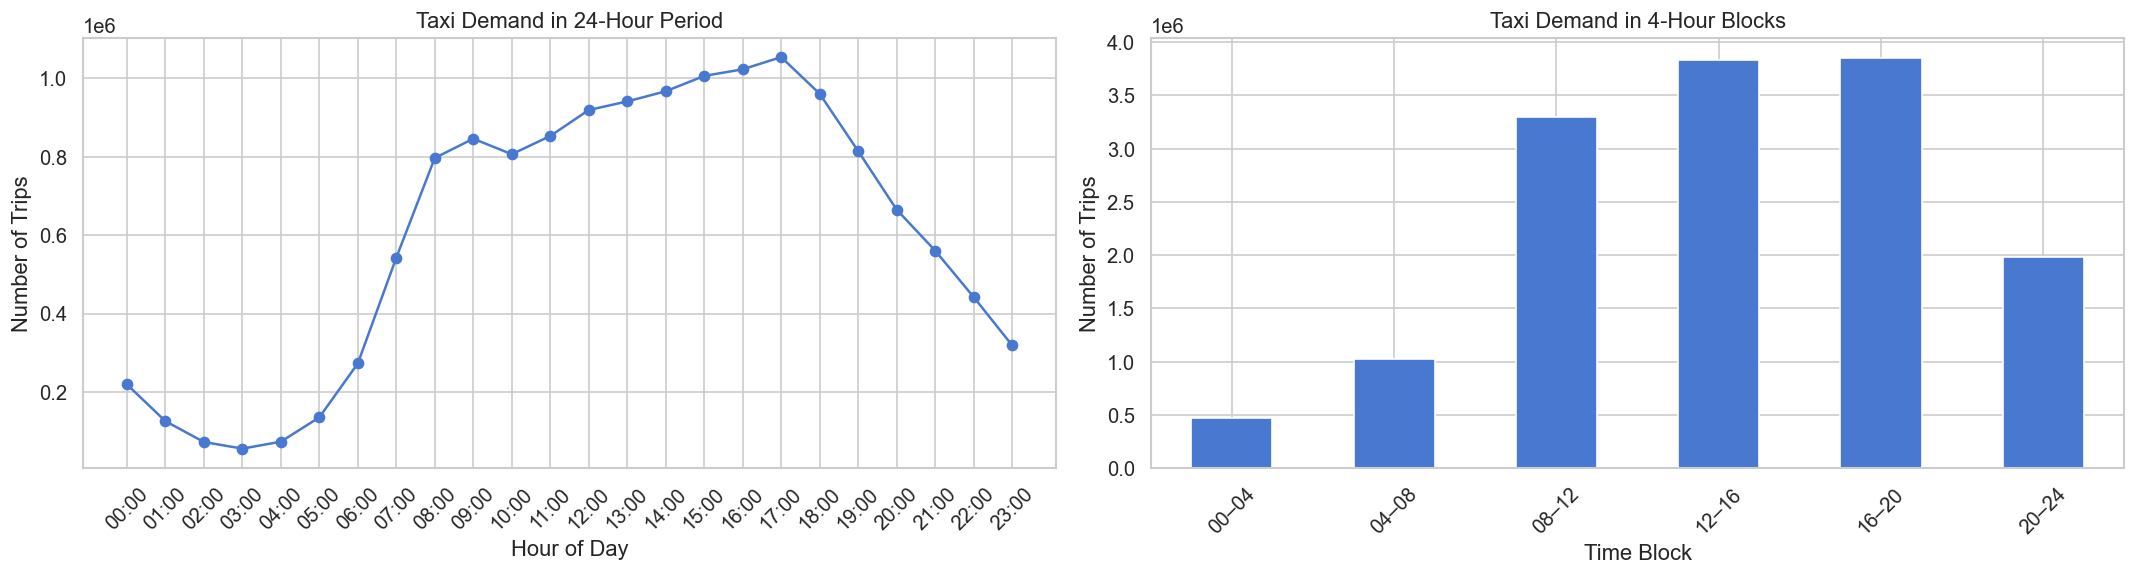

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

df_taxi["hour"] = df_taxi["trip_start_timestamp"].dt.hour
hour_profile = (
    df_taxi
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

df_taxi["time_block"] = pd.cut(
    df_taxi["hour"],
    bins=[0, 4, 8, 12, 16, 20, 24],
    labels=["00–04", "04–08", "08–12", "12–16", "16–20", "20–24"],
    right=False
)

block_profile = (
    df_taxi
    .groupby("time_block", observed=False)
    .size()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(hour_profile.index, hour_profile.values, marker="o")
axes[0].set_title("Taxi Demand in 24-Hour Period")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Trips")
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

block_profile.plot(kind="bar", ax=axes[1])
axes[1].set_title("Taxi Demand in 4-Hour Blocks")
axes[1].set_xlabel("Time Block")
axes[1].set_ylabel("Number of Trips")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.5 Weekend Demand by Time of Day

Separate Friday-to-Sunday profiles test whether the weekly temporal pattern changes during leisure-oriented periods. Demand remains concentrated during daytime and evening hours, and the expected strong overnight weekend peak is not observed. Weekend demand is therefore lower in level but does not exhibit a fundamentally different late-night pattern that would justify a separate overnight operating regime.

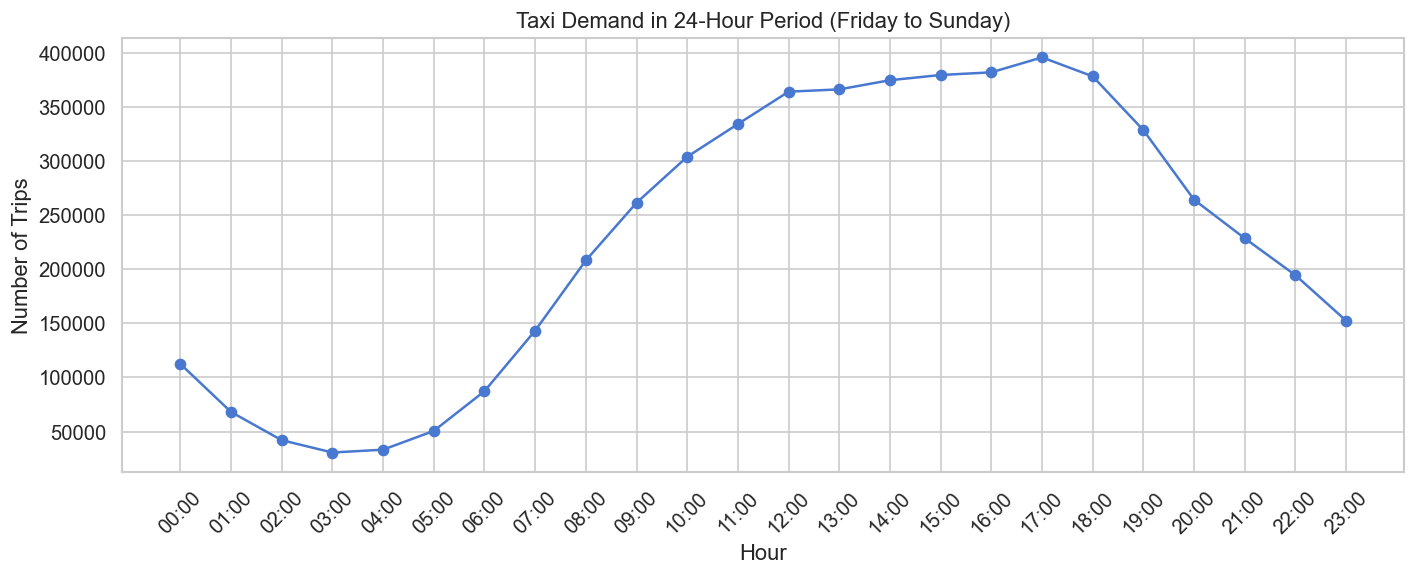

In [51]:

df_taxi["weekday"] = df_taxi["trip_start_timestamp"].dt.day_name()
df_taxi["hour"] = df_taxi["trip_start_timestamp"].dt.hour


fri_sun = df_taxi[
    df_taxi["weekday_name"].isin(["Friday", "Saturday", "Sunday"])
]

fri_sun_profile = (
    fri_sun
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(fri_sun_profile.index, fri_sun_profile.values, marker="o")

plt.title("Taxi Demand in 24-Hour Period (Friday to Sunday)")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")

plt.xticks(
    ticks=range(24),
    labels=[f"{h:02d}:00" for h in range(24)],
    rotation=45
)

plt.tight_layout()
plt.show()

## 4. Trip Characteristics – Distance, Duration, and Price

This section describes the operational profile of a typical taxi trip and the right-skewed distributions of distance, duration, and cost. Medians represent a typical trip, while means capture the influence of long airport and cross-city journeys.

### 4.1 Distance, Duration, and Fare Distributions

The distributions below compare typical values with their long upper tails. Fare values are clipped at the 99th percentile for visualization only; all summary statistics use the complete cleaned values.

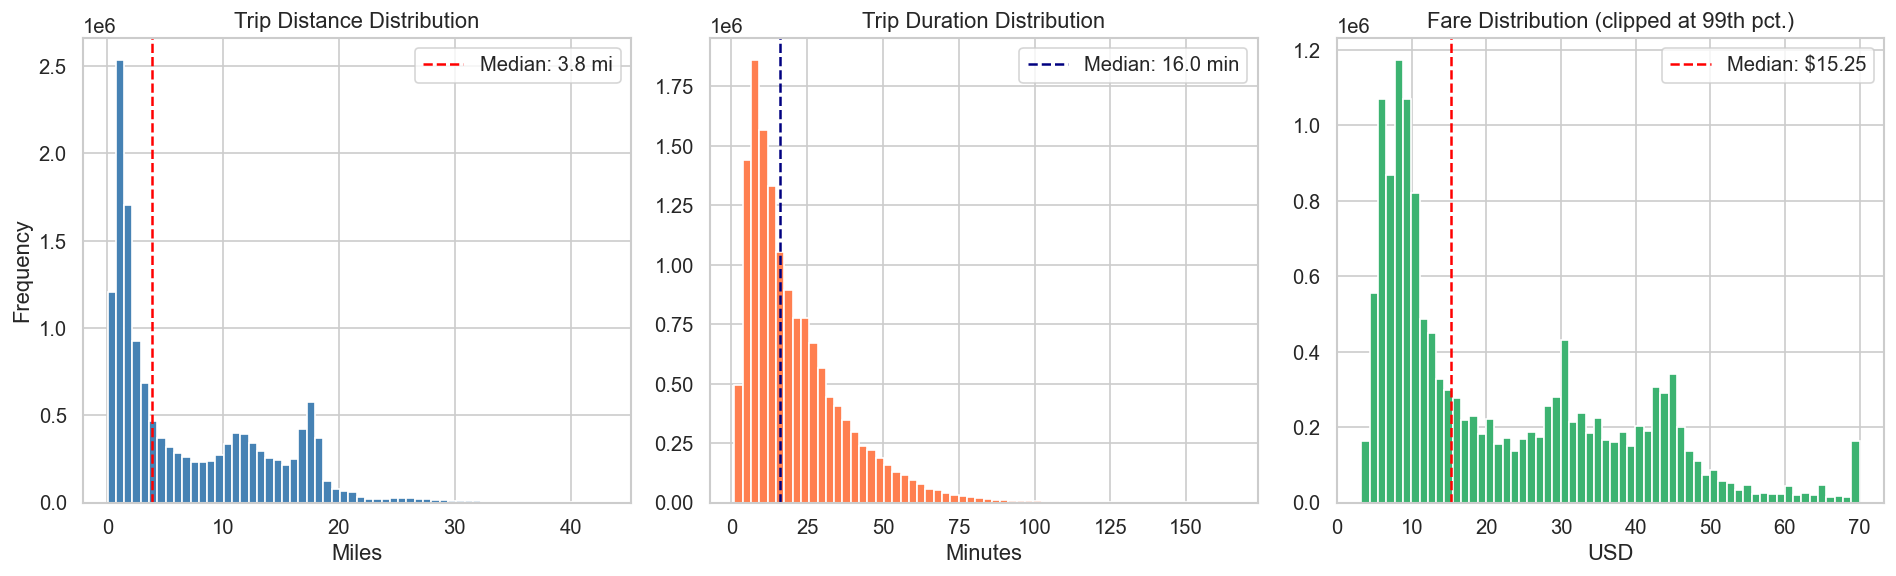

        trip_miles  trip_minutes         fare   trip_total
count  14465662.00   14465662.00  14465662.00  14465662.00
mean          7.09         20.97        22.06        27.01
std           6.76         16.17        16.86        23.21
min           0.01          1.00         3.25         3.25
25%           1.40          9.00         8.50        10.50
50%           3.85         16.00        15.25        17.75
75%          12.20         28.35        33.50        40.50
max          43.03        165.37      6950.69      8940.88


In [52]:
# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distance
axes[0].hist(df_taxi['trip_miles'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Trip Distance Distribution')
axes[0].set_xlabel('Miles')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_taxi['trip_miles'].median(), color='red', linestyle='--',
                label=f'Median: {df_taxi["trip_miles"].median():.1f} mi')
axes[0].legend()

# Duration (in minutes)
df_taxi['trip_minutes'] = df_taxi['trip_seconds'] / 60
axes[1].hist(df_taxi['trip_minutes'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Trip Duration Distribution')
axes[1].set_xlabel('Minutes')
axes[1].axvline(df_taxi['trip_minutes'].median(), color='navy', linestyle='--',
                label=f'Median: {df_taxi["trip_minutes"].median():.1f} min')
axes[1].legend()

# Fare
axes[2].hist(df_taxi['fare'].clip(upper=df_taxi['fare'].quantile(0.99)), bins=60,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Fare Distribution (clipped at 99th pct.)')
axes[2].set_xlabel('USD')
axes[2].axvline(df_taxi['fare'].median(), color='red', linestyle='--',
                label=f'Median: ${df_taxi["fare"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(df_taxi[['trip_miles', 'trip_minutes', 'fare', 'trip_total']].describe().round(2))

### 4.2 Average Trip Speed

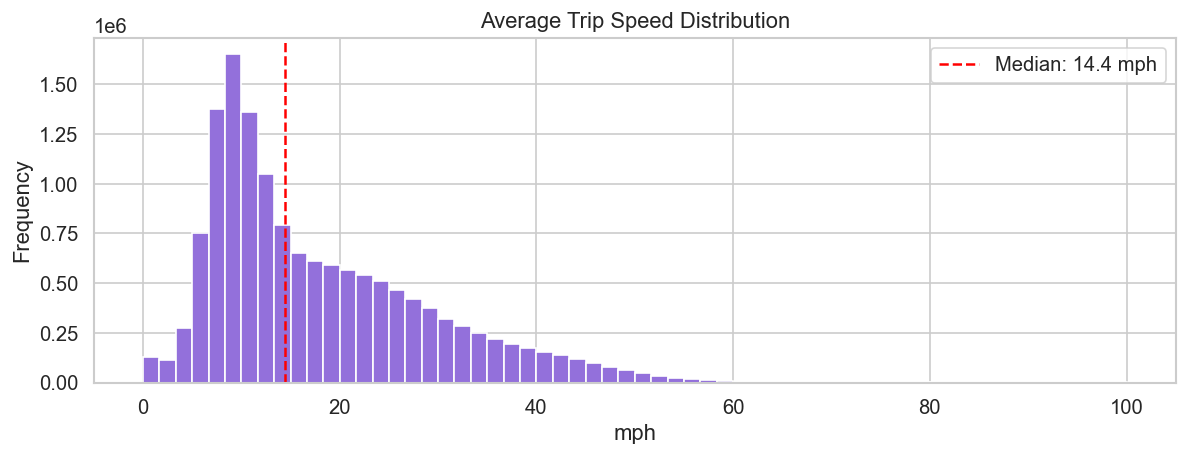

In [53]:
# ── Average speed (mph) ────────────────────────────────────────────────────────
df_taxi['speed_mph'] = (df_taxi['trip_miles'] / (df_taxi['trip_seconds'] / 3600)).clip(upper=100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_taxi['speed_mph'].dropna(), bins=60, color='mediumpurple', edgecolor='white')
ax.axvline(df_taxi['speed_mph'].median(), color='red', linestyle='--',
           label=f'Median: {df_taxi["speed_mph"].median():.1f} mph')
ax.set_title('Average Trip Speed Distribution')
ax.set_xlabel('mph')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Relationship Between Distance and Fare

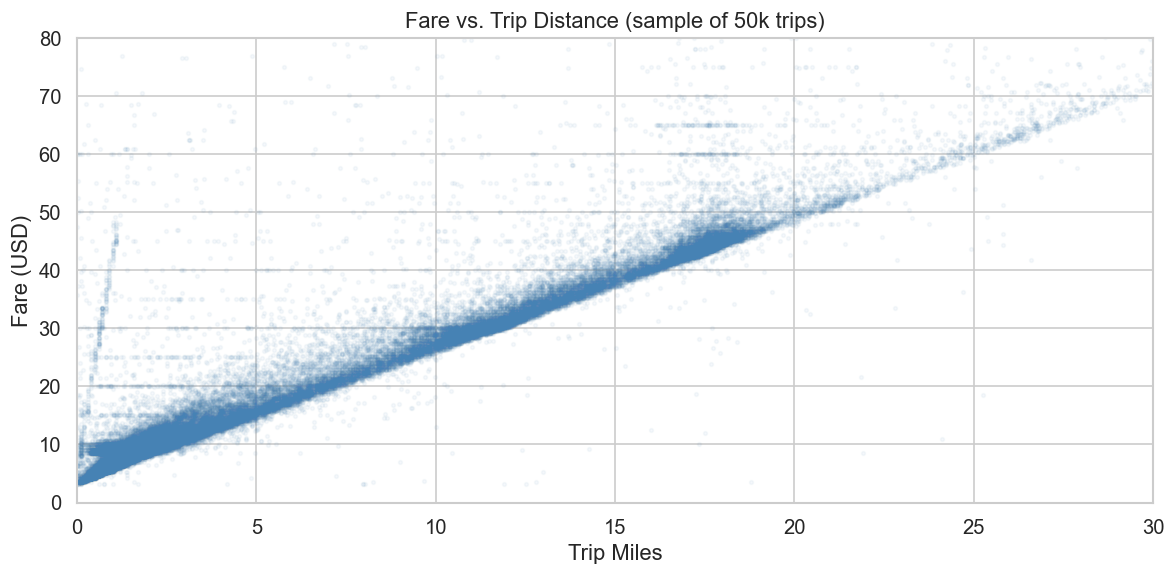

In [54]:
# ── Fare vs. Distance scatterplot (sampled for performance) ───────────────────
sample = df_taxi.sample(min(50_000, len(df_taxi)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['trip_miles'], sample['fare'], alpha=0.05, s=5, color='steelblue')
ax.set_title('Fare vs. Trip Distance (sample of 50k trips)')
ax.set_xlabel('Trip Miles')
ax.set_ylabel('Fare (USD)')
ax.set_xlim(0, 30)
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

### 4.4 Fare Variation by Hour

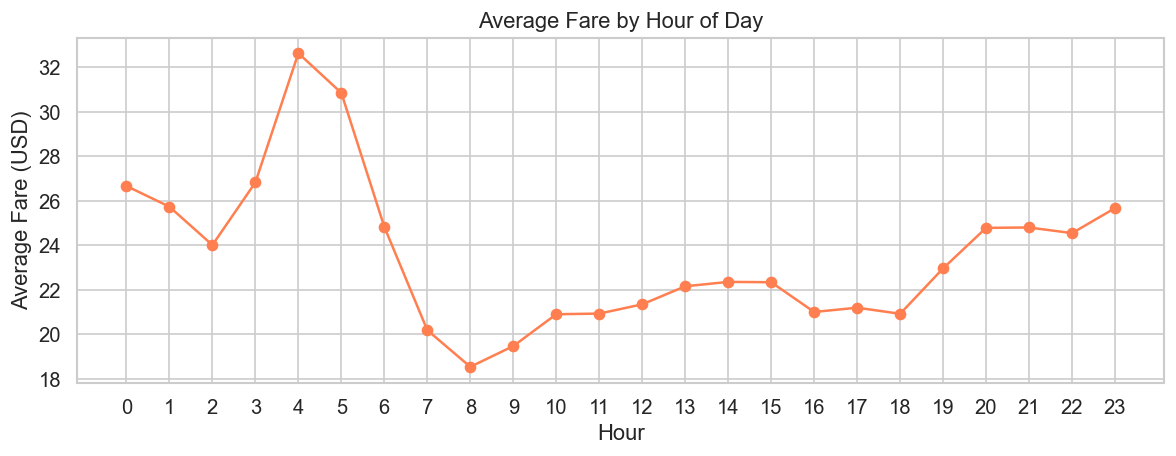

In [55]:
# ── Average fare by hour of day ───────────────────────────────────────────────
avg_fare_hour = df_taxi.groupby('hour')['fare'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(avg_fare_hour.index, avg_fare_hour.values, marker='o', color='coral')
ax.set_title('Average Fare by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Average Fare (USD)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 5. Spatial Demand Patterns

This section examines where trips start and end, which community areas generate the most pickups, and how often trips remain within Chicago. Coordinates represent census-tract or community-area centroids and must therefore not be interpreted as exact street-level locations.

### 5.1 Pickup and Drop-off Density

Density maps provide a city-wide view of spatial concentration. They are suitable for identifying broad operating zones, not precise curb-level pickup locations.

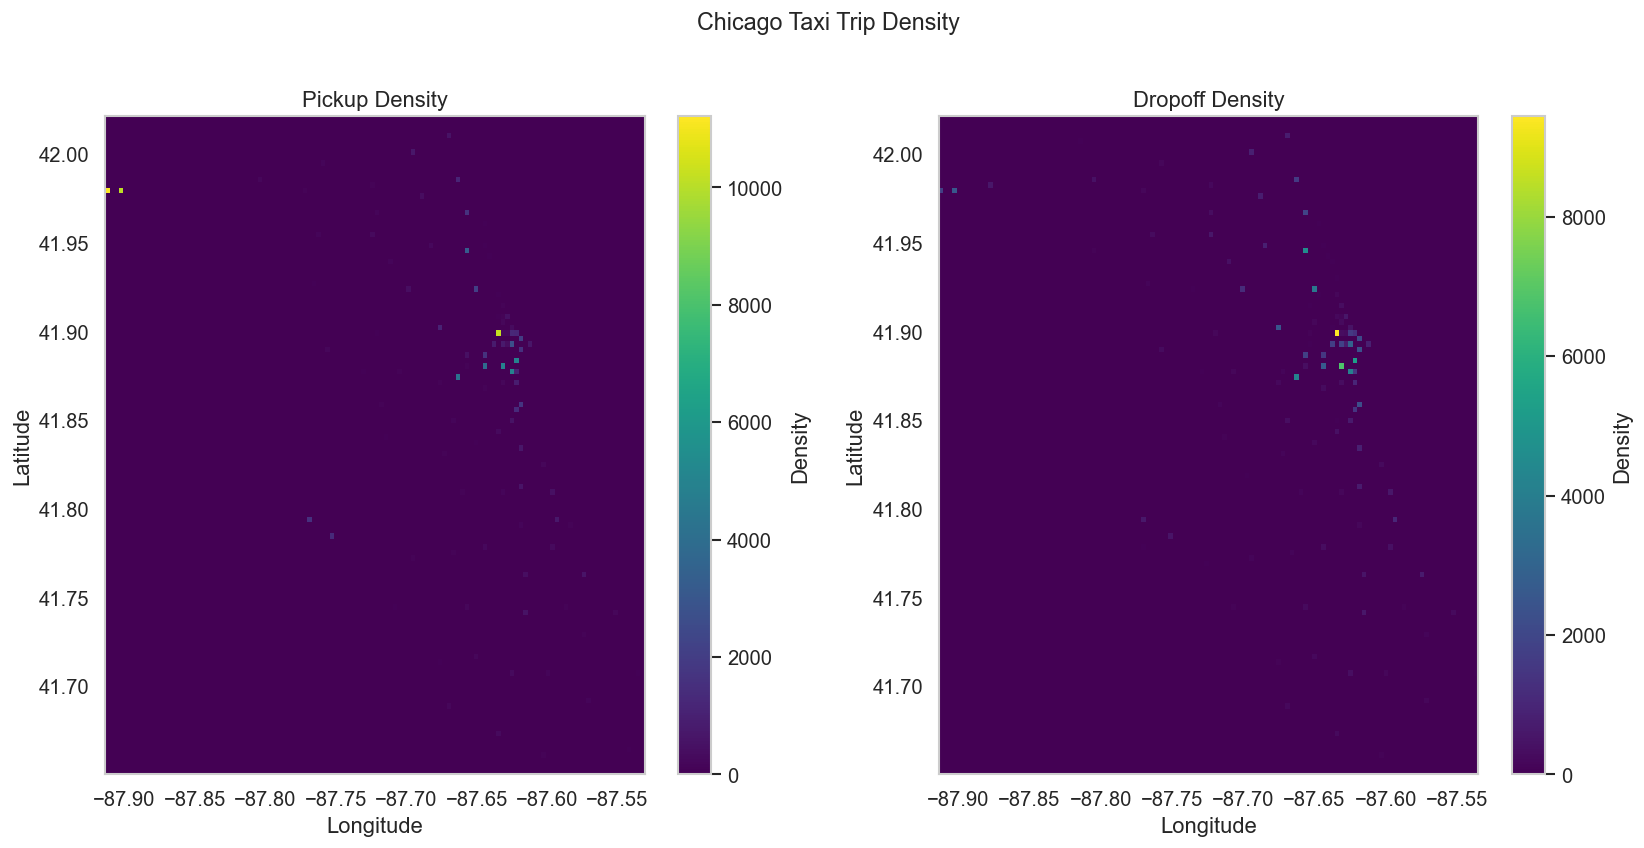

Trips with valid pickup coordinates: 14,203,555


In [56]:
# ── Trip density map (2D histogram) ──────────────────────────────────────────
LAT_MIN, LAT_MAX = 41.6, 42.1
LON_MIN, LON_MAX = -87.95, -87.5

spatial = df_taxi[
    df_taxi['pickup_centroid_latitude'].between(LAT_MIN, LAT_MAX) &
    df_taxi['pickup_centroid_longitude'].between(LON_MIN, LON_MAX)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, lat_col, lon_col, title in [
    (axes[0], 'pickup_centroid_latitude',  'pickup_centroid_longitude',  'Pickup Density'),
    (axes[1], 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'Dropoff Density'),
]:
    h = ax.hist2d(
        spatial[lon_col].dropna(),
        spatial[lat_col].dropna(),
        bins=120,
        cmap='viridis',
        density=True,
    )
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Chicago Taxi Trip Density', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trips with valid pickup coordinates: {len(spatial):,}')

### 5.2 Highest-Demand Community Areas

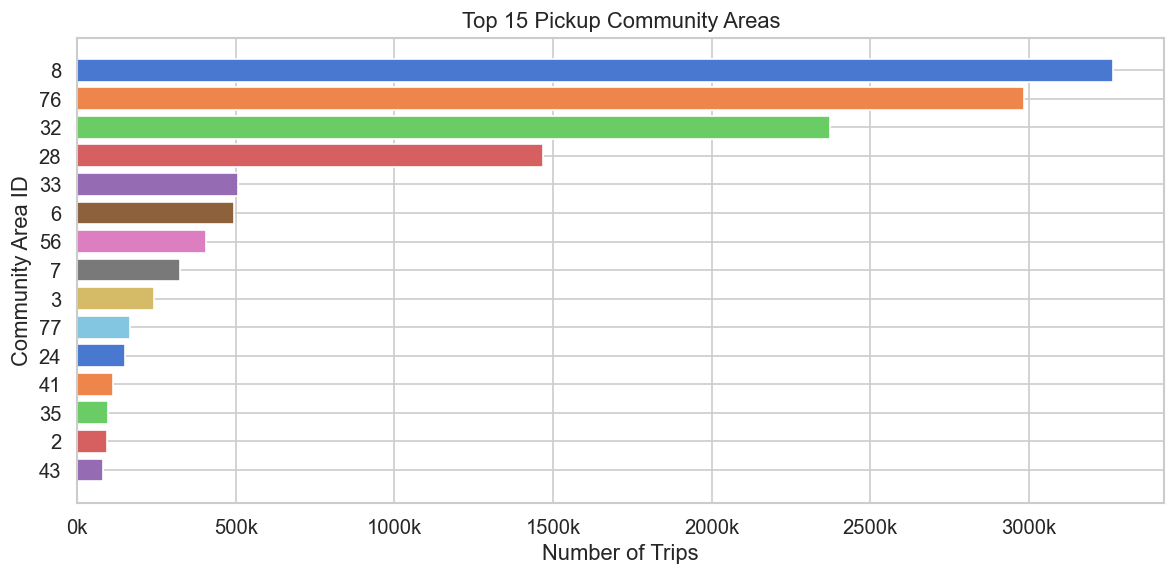

In [57]:
# ── Top 15 pickup community areas ─────────────────────────────────────────────
top_pickup = (
    df_taxi['pickup_community_area']
    .value_counts()
    .head(15)
    .reset_index()
)
top_pickup.columns = ['community_area', 'trips']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_pickup['community_area'].astype(str), top_pickup['trips'],
               color=sns.color_palette('muted', 15))
ax.invert_yaxis()
ax.set_title('Top 15 Pickup Community Areas')
ax.set_xlabel('Number of Trips')
ax.set_ylabel('Community Area ID')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

### 5.3 Trips Within and Outside Chicago

Pickup and drop-off community-area availability is used to distinguish trips that remain within Chicago from trips with an origin, destination, or unclear location outside the city boundary. Missing community areas are retained rather than discarded.

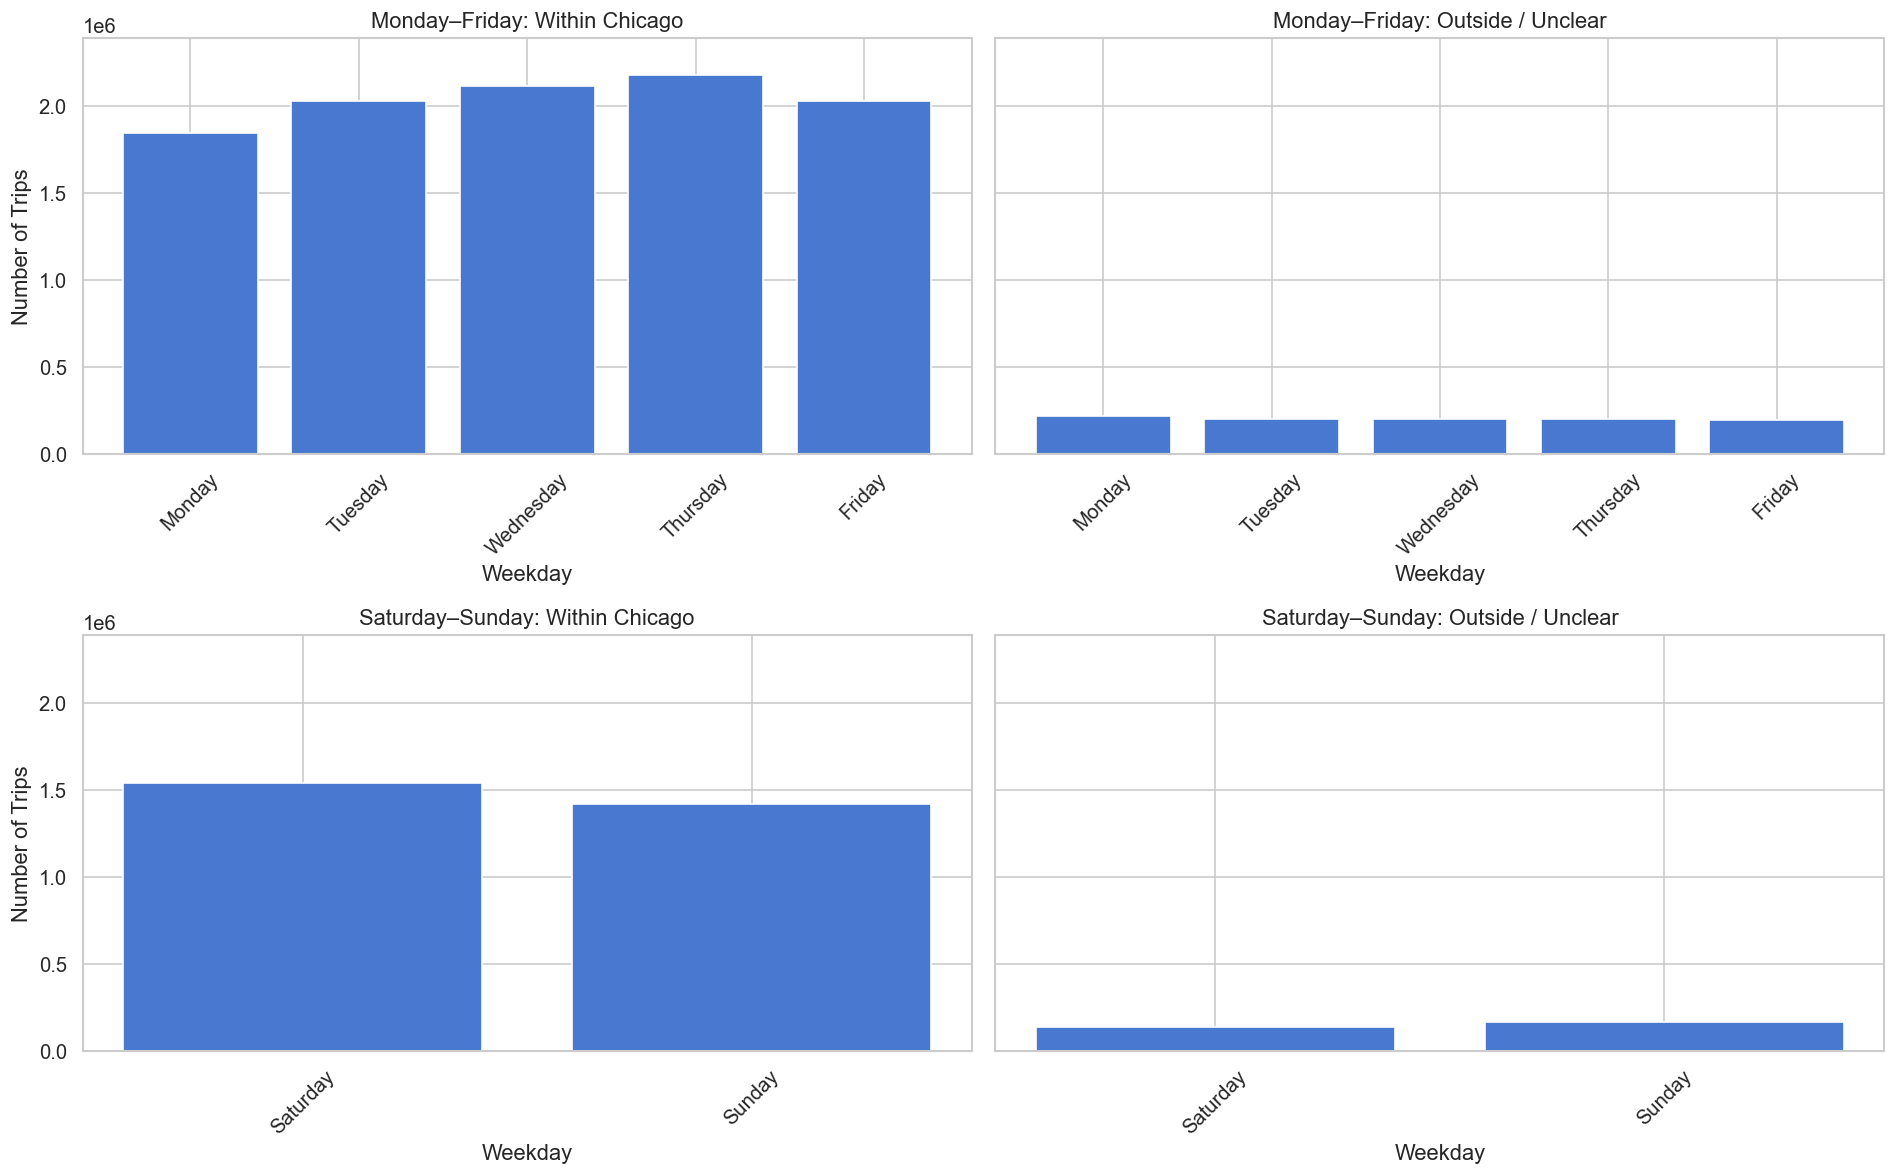

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


if "weekday_name" not in df_taxi.columns:
    df_taxi["weekday_name"] = df_taxi["trip_start_timestamp"].dt.day_name()

df_plot = df_taxi[["weekday_name", "pickup_community_area", "dropoff_community_area"]].copy()

# Robust handling of community areas:
# Missing values are kept, but counted as False for the Chicago scope check.
df_plot["pickup_in_chicago"] = (
    pd.to_numeric(df_plot["pickup_community_area"], errors="coerce")
    .between(1, 77, inclusive="both")
    .fillna(False)
)

df_plot["dropoff_in_chicago"] = (
    pd.to_numeric(df_plot["dropoff_community_area"], errors="coerce")
    .between(1, 77, inclusive="both")
    .fillna(False)
)

df_plot["trip_scope"] = np.where(
    df_plot["pickup_in_chicago"] & df_plot["dropoff_in_chicago"],
    "Within Chicago",
    "Outside / Unclear"
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekend_order = ["Saturday", "Sunday"]

# Helper function
def counts_by_day(data, day_order):
    return data["weekday_name"].value_counts().reindex(day_order, fill_value=0)

weekday_within = counts_by_day(
    df_plot[
        (df_plot["weekday_name"].isin(weekday_order)) &
        (df_plot["trip_scope"] == "Within Chicago")
    ],
    weekday_order
)

weekday_outside = counts_by_day(
    df_plot[
        (df_plot["weekday_name"].isin(weekday_order)) &
        (df_plot["trip_scope"] == "Outside / Unclear")
    ],
    weekday_order
)

weekend_within = counts_by_day(
    df_plot[
        (df_plot["weekday_name"].isin(weekend_order)) &
        (df_plot["trip_scope"] == "Within Chicago")
    ],
    weekend_order
)

weekend_outside = counts_by_day(
    df_plot[
        (df_plot["weekday_name"].isin(weekend_order)) &
        (df_plot["trip_scope"] == "Outside / Unclear")
    ],
    weekend_order
)

# Shared y-axis for better comparability
max_count = max(
    weekday_within.max(),
    weekday_outside.max(),
    weekend_within.max(),
    weekend_outside.max()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

axes[0, 0].bar(weekday_within.index, weekday_within.values)
axes[0, 0].set_title("Monday–Friday: Within Chicago")
axes[0, 0].set_xlabel("Weekday")
axes[0, 0].set_ylabel("Number of Trips")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_ylim(0, max_count * 1.1)

axes[0, 1].bar(weekday_outside.index, weekday_outside.values)
axes[0, 1].set_title("Monday–Friday: Outside / Unclear")
axes[0, 1].set_xlabel("Weekday")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylim(0, max_count * 1.1)

axes[1, 0].bar(weekend_within.index, weekend_within.values)
axes[1, 0].set_title("Saturday–Sunday: Within Chicago")
axes[1, 0].set_xlabel("Weekday")
axes[1, 0].set_ylabel("Number of Trips")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].set_ylim(0, max_count * 1.1)

axes[1, 1].bar(weekend_outside.index, weekend_outside.values)
axes[1, 1].set_title("Saturday–Sunday: Outside / Unclear")
axes[1, 1].set_xlabel("Weekday")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].set_ylim(0, max_count * 1.1)

plt.tight_layout()
plt.show()

## 6. Results and Key Takeaways

The exploratory analysis of **14,465,662 cleaned trips** from January 2024 through May 2026 yields the following conclusions:

- **Demand follows a stable daily rhythm.** The lowest volume occurs at 03:00 and the highest at 17:00. Demand rises rapidly during the morning and remains elevated through the afternoon and early evening.
- **Weekdays are substantially busier than weekends.** After normalizing by the number of observed calendar days, Thursday records the highest average demand at approximately 18,856 trips per day, followed by Wednesday at 18,358. Sunday is lowest at approximately 12,591 trips.
- **Trip characteristics are strongly right-skewed.** The median trip covers 3.85 miles, lasts 16.00 minutes, has a metered fare of $15.25, and costs $17.75 in total. The corresponding means are higher because a smaller number of long and expensive trips influence the averages.
- **Demand is spatially concentrated.** Near North Side, O'Hare, the Loop, and Near West Side together account for approximately 71% of pickups with a reported community area.
- **Temporal discretization changes the operational signal.** Hourly data retain short-lived peaks for tactical positioning, four-hour blocks reduce noise for more stable fleet-allocation models, and daily aggregation is best suited to longer-term capacity trends.

**Interpretation limits.** The year 2026 is observed only through May, so raw annual or monthly totals are not directly comparable with the two complete years. Spatial coordinates are anonymized centroids, and the data describe observed licensed-taxi trips rather than all latent ride-hailing demand. Idle time is not estimated in this notebook because a valid calculation requires complete vehicle-level trip sequences and explicit separation of off-shift periods.